In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (1000, 8)

Columns:
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [6]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [7]:
X = df_encoded.drop('math score', axis=1)
y = df_encoded['math score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

print("MULTIPLE LINEAR")
print("MSE:", mean_squared_error(y_test, pred_lin))
print("R2:", r2_score(y_test, pred_lin))

MULTIPLE LINEAR
MSE: 29.095169866715487
R2: 0.8804332983749565


In [9]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

print("\nLASSO")
print("MSE:", mean_squared_error(y_test, pred_lasso))
print("R2:", r2_score(y_test, pred_lasso))


LASSO
MSE: 28.98229737340729
R2: 0.8808971482782525


In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

print("\nRIDGE")
print("MSE:", mean_squared_error(y_test, pred_ridge))
print("R2:", r2_score(y_test, pred_ridge))


RIDGE
MSE: 29.12124087111447
R2: 0.8803261594918251


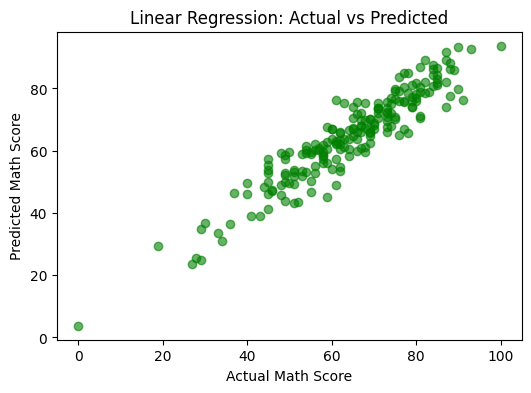

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, pred_lin, color='green', alpha=0.6)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

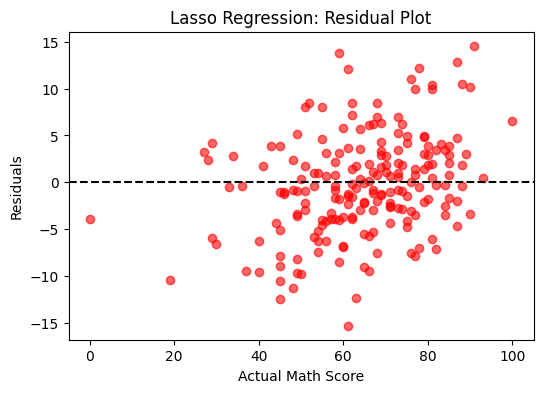

In [13]:
residuals_lasso = y_test - pred_lasso
plt.figure(figsize=(6,4))
plt.scatter(y_test, residuals_lasso, color='red', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Actual Math Score")
plt.ylabel("Residuals")
plt.title("Lasso Regression: Residual Plot")
plt.show()

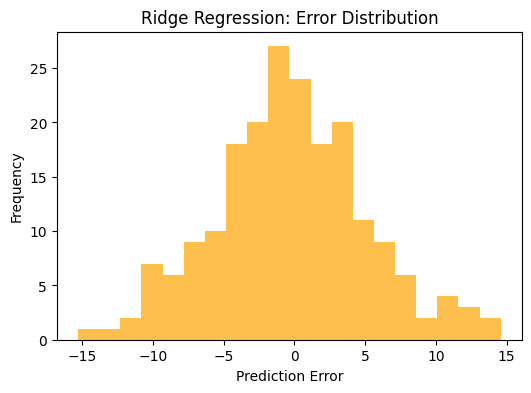

In [14]:
errors_ridge = y_test - pred_ridge
plt.figure(figsize=(6,4))
plt.hist(errors_ridge, bins=20, color='orange', alpha=0.7)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Ridge Regression: Error Distribution")
plt.show()